<a href="https://colab.research.google.com/github/pao0430jimenez-eng/METODOS-NUMERICOS-2/blob/main/Integraci%C3%B3n_de_Romberg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integración de Romberg

> Metodos Numericos II



## Método de Romberg

El método combina la **regla compuesta del trapecio** con la **extrapolación de Richardson**.

La aproximación inicial es:

$$
R_{1,1}=\frac{b-a}{2}[f(a)+f(b)].
$$

En cada fila se divide el paso entre dos:

$$
h_i=\frac{b-a}{2^{i-1}}.
$$

La primera columna se calcula reutilizando la aproximación anterior y evaluando únicamente los puntos nuevos:

$$
R_{i,1}=\frac{R_{i-1,1}}{2}
+h_i\sum_{k=1}^{2^{i-2}}f\left(a+(2k-1)h_i\right).
$$

Las siguientes columnas se obtienen de la siguiente forma:

$$
R_{i,j}=R_{i,j-1}
+\frac{R_{i,j-1}-R_{i-1,j-1}}{4^{j-1}-1}.
$$

La aproximación final es el elemento de la última fila y última columna.

**Nota:** los índices matemáticos comienzan en 1, pero los índices de Python comienzan en 0. Por eso `R[0,0]` representa $R_{1,1}$.

Realizaremos el método de Integración de Romberg y lo utilizaremos para resolver el ejemplo 2 de la página 160 de Burden.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# numpy: operaciones matemáticas y arreglos.
# pandas: presentación de la tabla.
# matplotlib: elaboración de gráficas.

In [2]:
def romberg(f, a, b, n):
    """
    Calcula n filas de la tabla de Romberg.

    f: función que se desea integrar.
    a, b: límites de integración.
    n: número de filas.
    """
    if not isinstance(n, int) or isinstance(n, bool) or n < 1:
        raise ValueError("n debe ser un entero positivo.")

    # Las posiciones fuera del triángulo quedan vacías.
    R = np.full((n, n), np.nan)

    h = b - a

    # Primera aproximación: regla del trapecio.
    R[0, 0] = h * (f(a) + f(b)) / 2

    for i in range(1, n):
        # Reducir el paso a la mitad.
        h = h / 2

        suma = 0.0

        # Evaluar únicamente los puntos nuevos.
        for k in range(1, 2**(i - 1) + 1):
            x = a + (2*k - 1)*h
            suma += f(x)

        # Primera columna de la fila actual.
        R[i, 0] = R[i - 1, 0]/2 + h*suma

        # Extrapolación de Richardson.
        for j in range(1, i + 1):
            R[i, j] = R[i, j - 1] + (
                R[i, j - 1] - R[i - 1, j - 1]
            ) / (4**j - 1)

    return R

como funciona cada cosa:

- `def` permite definir una función.
- `np.full((n,n), np.nan)` crea una matriz de tamaño $n\times n$.
- `range(1,n)` recorre los enteros desde 1 hasta $n-1$.
- `**` representa una potencia.
- `suma += f(x)` equivale a `suma = suma + f(x)`.
- `return R` devuelve la tabla calculada.

**Nota:** Se conserva toda la tabla para mostrar el procedimiento. Si únicamente se necesitara el resultado final, bastaría almacenar la fila anterior y la actual.

In [9]:
# Función del ejemplo. np.sin utiliza radianes.
def f(x):
    return np.sin(x)

a = 0.0
b = np.pi
n = 6

R = romberg(f, a, b, n)

# Convertir la matriz en una tabla.
tabla = pd.DataFrame(
    R,
    index=[f"Fila {i}" for i in range(1, n + 1)],
    columns=[f"Columna {j}" for j in range(1, n + 1)]
)

# Mostrar diez decimales y dejar vacías las posiciones no utilizadas.
display(
    tabla.style
    .format("{:.10f}", na_rep="")
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#fff176"),
                ("color", "#6A0DAD")
            ]
        }
    ])
)

print("Sexta fila de Romberg:\n")

for j in range(n):
    print(f"R(6,{j + 1}) = {R[5, j]:.8f}")

,Columna 1,Columna 2,Columna 3,Columna 4,Columna 5,Columna 6
Fila 1,0.0000000000,,,,,
Fila 2,1.5707963268,2.0943951024,,,,
Fila 3,1.8961188979,2.0045597550,1.9985707318,,,
Fila 4,1.9742316019,2.0002691699,1.9999831309,2.0000055500,,
Fila 5,1.9935703438,2.0000165910,1.9999997525,2.0000000163,1.9999999946,
Fila 6,1.9983933610,2.0000010334,1.9999999962,2.0000000001,2.0000000000,2.0000000000


Sexta fila de Romberg:

R(6,1) = 1.99839336
R(6,2) = 2.00000103
R(6,3) = 2.00000000
R(6,4) = 2.00000000
R(6,5) = 2.00000000
R(6,6) = 2.00000000


R(6,1) = 1.99839336
R(6,2) = 2.00000103
R(6,3) = 2.00000000
R(6,4) = 2.00000000
R(6,5) = 2.00000000
R(6,6) = 2.00000000


La sexta fila empieza con:

$$
R_{6,1}=
\frac12\left[
R_{5,1}+\frac{\pi}{16}
\sum_{k=1}^{16}
\sin\left(\frac{(2k-1)\pi}{32}\right)
\right]
\approx 1.99839336.
$$

Después se aplican las extrapolaciones con denominadores:

$$
3,\quad 15,\quad 63,\quad 255,\quad 1023.
$$

Por ejemplo:

$$
R_{6,2}=R_{6,1}+\frac{R_{6,1}-R_{5,1}}{3}
\approx 2.00000103.
$$



In [6]:
# -1 selecciona la última posición.
aproximacion = R[-1, -1]

valor_exacto = 2.0
error_absoluto = abs(valor_exacto - aproximacion)

print(f"Aproximación: {aproximacion:.15f}")
print(f"Valor exacto: {valor_exacto:.15f}")
print(f"Error absoluto: {error_absoluto:.3e}")

display(HTML(f"""
<div style="background-color:#fff176;
            color:#000000;
            padding:15px;
            border-left:5px solid #fbc02d;">
    <b>Solución final</b><br>
    La integral de sen(x) desde 0 hasta π es aproximadamente
    <b>{aproximacion:.10f}</b>.
</div>
"""))

Aproximación: 2.000000000001321
Valor exacto: 2.000000000000000
Error absoluto: 1.321e-12


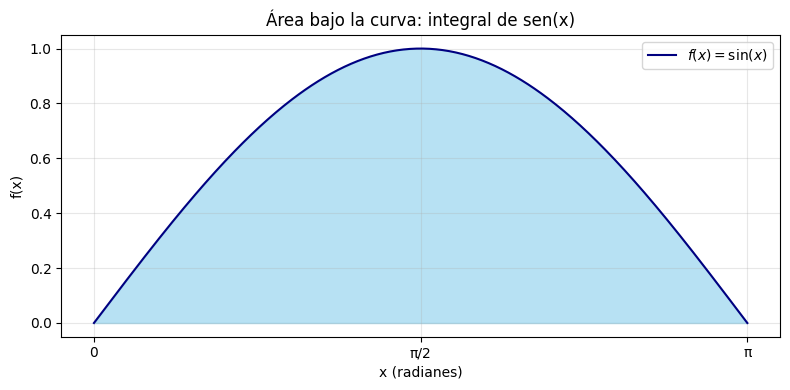

In [5]:
x = np.linspace(a, b, 400)
y = f(x)

plt.figure(figsize=(8, 4))

plt.plot(x, y, color="navy", label=r"$f(x)=\sin(x)$")
plt.fill_between(x, 0, y, color="skyblue", alpha=0.6)

plt.title("Área bajo la curva: integral de sen(x)")
plt.xlabel("x (radianes)")
plt.ylabel("f(x)")

plt.xticks(
    [0, np.pi/2, np.pi],
    ["0", "π/2", "π"]
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



Se realizo la tabla de Romberg con seis filas con la integral de
$\sin(x)$ en el intervalo $[0,\pi]$.

La aproximación trapezoidal de la sexta fila fue:

$$
\boxed {R_{6,1}\approx 1.99839336}
$$

La extrapolación, es:

$$
\boxed{R_{6,6}\approx 2.00000000}
$$
